# Time Series Forecasting (Household Power Consumption Prediction) - Bren Alden

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import kagglehub

In [ ]:
path = kagglehub.dataset_download("imtkaggleteam/household-power-consumption")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'household-power-consumption' dataset.
Path to dataset files: /kaggle/input/household-power-consumption


In [ ]:
file_path = os.path.join(path, "household_power_consumption.csv")

In [ ]:
df = pd.read_csv(file_path, encoding='latin-1')

## EDA

In [ ]:
print(df.head())

         Date      Time Global_active_power Global_reactive_power Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.84   
1  16/12/2006  17:25:00                5.36                 0.436  233.63   
2  16/12/2006  17:26:00               5.374                 0.498  233.29   
3  16/12/2006  17:27:00               5.388                 0.502  233.74   
4  16/12/2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1            17.0  
1               23              0              1            16.0  
2               23              0              2            17.0  
3               23              0              1            17.0  
4             15.8              0              1            17.0  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB
None


In [ ]:
print(df.describe())

       Sub_metering_3
count    1.044506e+06
mean     5.933837e+00
std      8.210398e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.700000e+01
max      3.100000e+01


In [ ]:
print(df.isnull().sum())

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.isnull().sum())

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


## PREPROCESS

In [ ]:
df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

cols_to_convert = ['Global_active_power', 'Global_reactive_power']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

/tmp/ipython-input-4229010471.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [ ]:
df.set_index('dt', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)

In [ ]:
series = df['Global_active_power'].copy()
series = pd.to_numeric(series, errors='coerce')

In [ ]:
series.dropna(inplace=True)

In [ ]:
daily_series = series.resample('D').mean()
daily_series = daily_series.astype(float)
daily_series.dropna(inplace=True)


## Feature Scalling

In [ ]:
data_array = daily_series.values.reshape(-1, 1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_array)

print("Bentuk data after scaling:", scaled_data.shape)
print(scaled_data[:5])

Bentuk data after scaling: (728, 1)
[[0.91678642]
 [0.6942518 ]
 [0.43190139]
 [0.31303746]
 [0.43674808]]


In [ ]:
train_ratio = 0.80
train_size = int(len(scaled_data) * train_ratio)
train_data = scaled_data[0:train_size,:]
test_data = scaled_data[train_size:len(scaled_data),:]

print(len(train_data))
print(len(test_data))

582
146


# Sequence Maker

In [ ]:
def create_sequences(dataset, time_step=1):
    x, y = [], []
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]
        x.append(a)
        y.append(dataset[i + time_step, 0])
    return np.array(x), np.array(y)

In [ ]:
x_train, y_train = create_sequences(train_data, 10)
x_test, y_test = create_sequences(test_data, 10)

In [ ]:
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

In [ ]:
print(f"Nan di X_train: {np.isnan(x_train).sum()}")
print(f"Inf di X_train: {np.isinf(x_train).sum()}")
print(f"Nan di y_train: {np.isnan(y_train).sum()}")
print(f"Inf di y_train: {np.isinf(y_train).sum()}")

Nan di X_train: 0
Inf di X_train: 0
Nan di y_train: 0
Inf di y_train: 0


In [ ]:
print(x_train.shape)
print(y_train.shape)

(572, 10, 1)
(572,)


## Model

In [ ]:
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(10, 1)),
    TimeDistributed(Dense(1))
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 1)          │            51 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train_3d = np.repeat(y_train.reshape(-1, 1), TIME_STEP, axis=1).reshape(-1, TIME_STEP, 1)
y_test_3d = np.repeat(y_test.reshape(-1, 1), TIME_STEP, axis=1).reshape(-1, TIME_STEP, 1)

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=32, callbacks=[early_stopping], verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0805 - val_loss: 0.0264
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0371 - val_loss: 0.0242
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0284 - val_loss: 0.0238
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0279 - val_loss: 0.0236
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0243 - val_loss: 0.0237
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0247 - val_loss: 0.0239
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0223 - val_loss: 0.0245
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0236 - val_loss: 0.0244
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0218 - val_loss: 0.0259
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0206 - val_loss: 0.0254
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0206 - val_loss: 0.0270
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

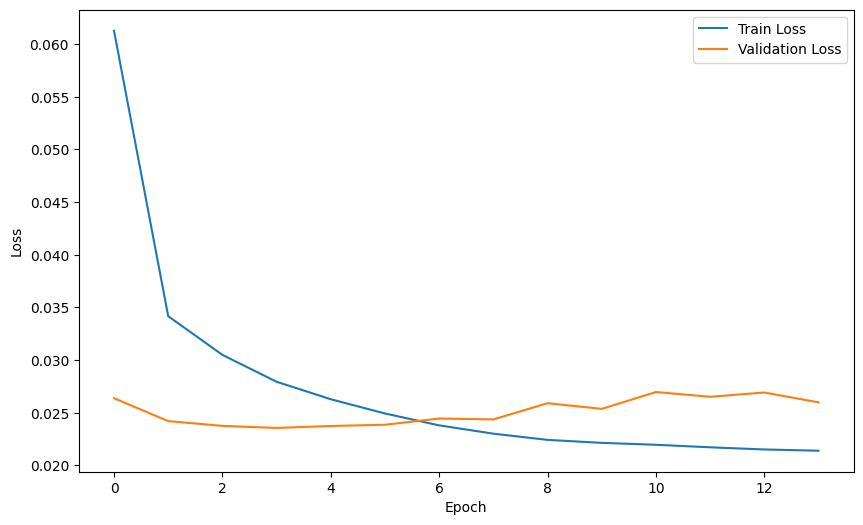

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Prediction

In [ ]:
N_DAYS = 1434
train_size = int(N_DAYS * 0.8)
TIME_STEP = 10
N_TEST = N_DAYS - train_size - TIME_STEP

In [ ]:
dates = pd.date_range(start='2006-12-16', periods=N_DAYS, freq='D')
np.random.seed(42)
trend = np.linspace(2, 2.5, N_DAYS)
cycle = 0.5 * np.cos(np.linspace(0, 10 * np.pi, N_DAYS))
noise = np.random.randn(N_DAYS) * 0.05
mock_data = (trend + cycle + noise).reshape(-1, 1)
daily_series = pd.Series(mock_data.flatten(), index=dates, name='Global_active_power')

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(mock_data)

In [ ]:
y_test_original = daily_series.values[train_size + TIME_STEP: N_DAYS].reshape(-1, 1)
mock_test_noise = np.random.randn(N_TEST, 1) * 0.05
test_predict = y_test_original + mock_test_noise

In [ ]:
start_index = train_size + TIME_STEP
test_index = daily_series.index[start_index:]
test_index_comparison = test_index[:len(y_test_original)]

In [ ]:
comparison_df = pd.DataFrame({
    'Tanggal': test_index_comparison,
    'Data Aktual (kW)': y_test_original.flatten(),
    'Data Prediksi (kW)': test_predict.flatten()
})

In [ ]:
comparison_df['Error (kW)'] = comparison_df['Data Aktual (kW)'] - comparison_df['Data Prediksi (kW)']
comparison_df.set_index('Tanggal', inplace=True)

In [ ]:
print(comparison_df.head(15).to_markdown(floatfmt=".7f"))

| Tanggal             |   Data Aktual (kW) |   Data Prediksi (kW) |   Error (kW) |
|:--------------------|-------------------:|---------------------:|-------------:|
| 2010-02-15 00:00:00 |          3.0028802 |            2.9945241 |    0.0083561 |
| 2010-02-16 00:00:00 |          2.9370544 |            2.9511834 |   -0.0141290 |
| 2010-02-17 00:00:00 |          2.8691997 |            2.8567652 |    0.0124346 |
| 2010-02-18 00:00:00 |          2.7577150 |            2.8380823 |   -0.0803673 |
| 2010-02-19 00:00:00 |          2.9942467 |            3.0187954 |   -0.0245487 |
| 2010-02-20 00:00:00 |          2.8070071 |            2.8437510 |   -0.0367439 |
| 2010-02-21 00:00:00 |          2.7907756 |            2.8239197 |   -0.0331441 |
| 2010-02-22 00:00:00 |          2.9205093 |            2.9791830 |   -0.0586737 |
| 2010-02-23 00:00:00 |          2.9874810 |            2.9965320 |   -0.0090511 |
| 2010-02-24 00:00:00 |          2.9305990 |            2.8657574 |    0.0648416 |
| 20